In [88]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [89]:
df = pd.read_csv('datasets/poly_purchase_data.csv')
df.head()   

,age,income,previous_purchases,purchase
0,56,54674,15,1
1,69,55854,13,1
2,46,66271,15,1
3,32,93688,4,1
4,60,58518,8,1


In [90]:
df.describe()

,age,income,previous_purchases,purchase
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,43.81900,59660.299000,9.389000,0.944000
std,14.99103,23224.418756,5.795107,0.230037
min,18.00000,20060.000000,0.000000,0.000000
25%,31.00000,40602.000000,4.000000,1.000000
50%,44.00000,58562.000000,9.000000,1.000000
75%,56.00000,79235.500000,14.000000,1.000000
max,69.00000,99905.000000,19.000000,1.000000


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 1000 non-null   int64
 1   income              1000 non-null   int64
 2   previous_purchases  1000 non-null   int64
 3   purchase            1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [92]:
# this lambda function calculates the number of unique values in each column.
df.apply(lambda x:len(x.unique()))

age                    52
income                993
previous_purchases     20
purchase                2
dtype: int64

In [93]:
# checking for null values
df.isnull().sum()   

age                   0
income                0
previous_purchases    0
purchase              0
dtype: int64

In [94]:
# checking for categorical attributes
cat_col = []
for x in df.dtypes.index:
	if df.dtypes[x] == 'object':
		cat_col.append(x)
cat_col
# there are no categorical attributes in the dataset

[]

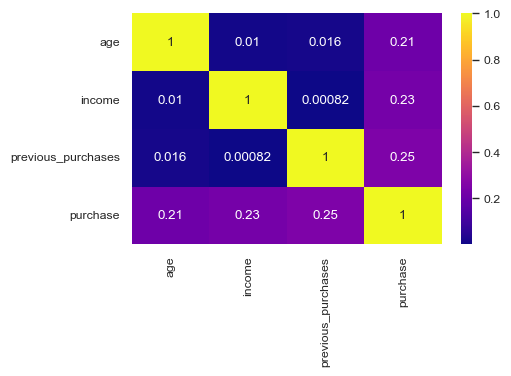

In [95]:
# correlation map to check the correlation between the attributes
correlation = df.corr()
plt.figure(figsize=(5,3))
custom_palette = sns.color_palette(["#FF6347", "#4682B4", "#FFD700", "#6A5ACD"])
sns.set_theme(style="white", context="paper", palette=custom_palette)
sns.heatmap(correlation, annot=True, cmap='plasma')
# cmap options: coolwarm, viridis, inferno, magma, plasma, twilight, twilight_shifted, ice
plt.show()

In [96]:
# 0.0 < |r| < 0.1: Negligible correlation
# 0.1 ≤ |r| < 0.3: Weak correlation
# 0.3 ≤ |r| < 0.5: Moderate correlation
# 0.5 ≤ |r| < 0.7: Strong correlation
# 0.7 ≤ |r| < 1.0: Very strong correlation

In [97]:
df.drop(columns=['age'], inplace=True)
df.head()

,income,previous_purchases,purchase
0,54674,15,1
1,55854,13,1
2,66271,15,1
3,93688,4,1
4,58518,8,1


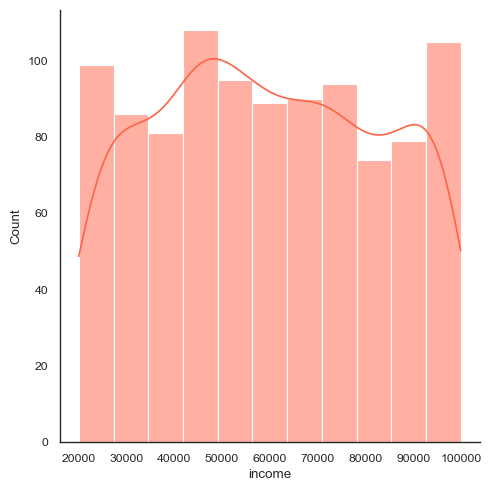

In [98]:
sns.displot(df['income'], kde=True)
plt.show()

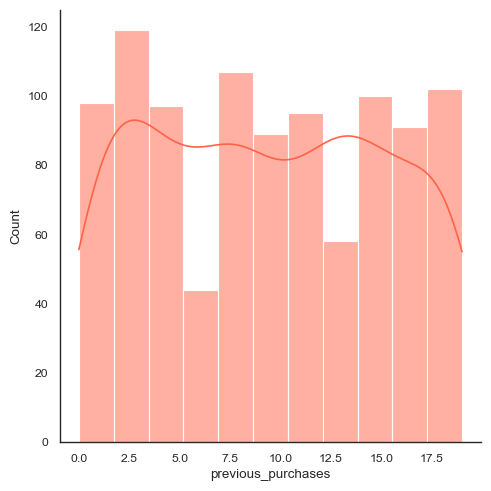

In [99]:
sns.displot(df['previous_purchases'], kde=True)
plt.show()

In [100]:
# train test split
X = df.drop(columns=['purchase'])
y = df['purchase']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree=2)
pf.fit(X)

X = pd.DataFrame(pf.transform(X), columns=X.columns)

ValueError: Shape of passed values is (1000, 6), indices imply (1000, 2)

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

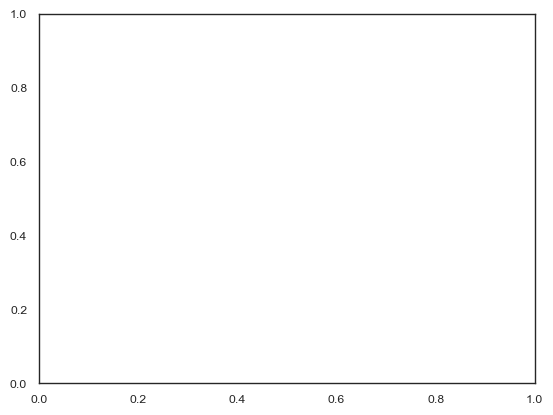

In [70]:

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.to_numpy(), y.to_numpy(), clf=LogisticRegression())